In [3]:
import numpy as np
import pandas as pd
import regex
import seaborn as sns
import matplotlib
from matplotlib import pyplot as plt


## Data Overview

Load the dataset and display the structure (rows, columns, data types).


In [ ]:
car=pd.read_csv('used_cars_data.csv',delimiter=',')

Identify and handle missing values across the dataset.


In [ ]:
car.isna().sum()

S.No.                   0
Name                    0
Location                0
Year                    0
Kilometers_Driven       0
Fuel_Type               0
Transmission            0
Owner_Type              0
Mileage                 2
Engine                 46
Power                  46
Seats                  53
New_Price            6247
Price                1234
dtype: int64

In [6]:
car.Mileage.mode()

0    17.0 kmpl
Name: Mileage, dtype: object

In [7]:
car.Mileage.fillna('17.0 kmpl',inplace=True)

/var/folders/fb/1__r2njx6m930p73dnkd_csm0000gn/T/ipykernel_97725/3825420700.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  car.Mileage.fillna('17.0 kmpl',inplace=True)


In [8]:
car.Engine.mode()

0    1197 CC
Name: Engine, dtype: object

In [9]:
car.Engine.fillna('1197 CC',inplace=True)

/var/folders/fb/1__r2njx6m930p73dnkd_csm0000gn/T/ipykernel_97725/531546390.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  car.Engine.fillna('1197 CC',inplace=True)


In [10]:
car.Power.mode()

0    74 bhp
Name: Power, dtype: object

In [11]:
car.Power.fillna('74 bhp',inplace=True)

/var/folders/fb/1__r2njx6m930p73dnkd_csm0000gn/T/ipykernel_97725/1414696958.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  car.Power.fillna('74 bhp',inplace=True)


In [12]:
car.Seats.mode()

0    5.0
Name: Seats, dtype: float64

In [13]:
car.Seats.fillna(5.0,inplace=True)

/var/folders/fb/1__r2njx6m930p73dnkd_csm0000gn/T/ipykernel_97725/3679624290.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  car.Seats.fillna(5.0,inplace=True)


In [14]:
car.isna().sum()

S.No.                   0
Name                    0
Location                0
Year                    0
Kilometers_Driven       0
Fuel_Type               0
Transmission            0
Owner_Type              0
Mileage                 0
Engine                  0
Power                   0
Seats                   0
New_Price            6247
Price                1234
dtype: int64

In [15]:
car.Price.median()

5.64

In [16]:
car.Price.fillna(5.64,inplace=True)

/var/folders/fb/1__r2njx6m930p73dnkd_csm0000gn/T/ipykernel_97725/2026276557.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  car.Price.fillna(5.64,inplace=True)


In [17]:
car.head()

,S.No.,Name,Location,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,New_Price,Price
0,0,Maruti Wagon R LXI CNG,Mumbai,2010,72000,CNG,Manual,First,26.6 km/kg,998 CC,58.16 bhp,5.0,NaN,1.75
1,1,Hyundai Creta 1.6 CRDi SX Option,Pune,2015,41000,Diesel,Manual,First,19.67 kmpl,1582 CC,126.2 bhp,5.0,NaN,12.50
2,2,Honda Jazz V,Chennai,2011,46000,Petrol,Manual,First,18.2 kmpl,1199 CC,88.7 bhp,5.0,8.61 Lakh,4.50
3,3,Maruti Ertiga VDI,Chennai,2012,87000,Diesel,Manual,First,20.77 kmpl,1248 CC,88.76 bhp,7.0,NaN,6.00
4,4,Audi A4 New 2.0 TDI Multitronic,Coimbatore,2013,40670,Diesel,Automatic,Second,15.2 kmpl,1968 CC,140.8 bhp,5.0,NaN,17.74


In [18]:
car['Mileage'] = car['Mileage'].str.extract(r'(\d+\.?\d*)')
car['Engine'] = car['Engine'].str.extract(r'(\d+\.?\d*)')
car['Power']  = car['Power'].str.extract(r'(\d+\.?\d*)')

In [19]:
car.head()

,S.No.,Name,Location,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,New_Price,Price
0,0,Maruti Wagon R LXI CNG,Mumbai,2010,72000,CNG,Manual,First,26.6,998,58.16,5.0,NaN,1.75
1,1,Hyundai Creta 1.6 CRDi SX Option,Pune,2015,41000,Diesel,Manual,First,19.67,1582,126.2,5.0,NaN,12.50
2,2,Honda Jazz V,Chennai,2011,46000,Petrol,Manual,First,18.2,1199,88.7,5.0,8.61 Lakh,4.50
3,3,Maruti Ertiga VDI,Chennai,2012,87000,Diesel,Manual,First,20.77,1248,88.76,7.0,NaN,6.00
4,4,Audi A4 New 2.0 TDI Multitronic,Coimbatore,2013,40670,Diesel,Automatic,Second,15.2,1968,140.8,5.0,NaN,17.74


In [20]:
car.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7253 entries, 0 to 7252
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   S.No.              7253 non-null   int64  
 1   Name               7253 non-null   object 
 2   Location           7253 non-null   object 
 3   Year               7253 non-null   int64  
 4   Kilometers_Driven  7253 non-null   int64  
 5   Fuel_Type          7253 non-null   object 
 6   Transmission       7253 non-null   object 
 7   Owner_Type         7253 non-null   object 
 8   Mileage            7253 non-null   object 
 9   Engine             7253 non-null   object 
 10  Power              7124 non-null   object 
 11  Seats              7253 non-null   float64
 12  New_Price          1006 non-null   object 
 13  Price              7253 non-null   float64
dtypes: float64(2), int64(3), object(9)
memory usage: 793.4+ KB


In [21]:
car['Mileage'] = car['Mileage'].astype(float)
car['Engine']  = car['Engine'].astype(int)
car['Power']   = car['Power'].astype(float)

Check for duplicate entries.


In [22]:
dup_count = car.duplicated().sum()
print(dup_count)

0


## Descriptive Analysis


Generate summary statistics (mean, median, std. dev., etc.) for numeric features like Price, Mileage, Power, Engine, Kilometers_Driven.

In [23]:
car.describe()

,S.No.,Year,Kilometers_Driven,Mileage,Engine,Power,Seats,Price
count,7253.000000,7253.000000,7.253000e+03,7253.000000,7253.000000,7124.000000,7253.000000,7253.000000
mean,3626.000000,2013.365366,5.869906e+04,18.141266,1613.912450,112.514905,5.277678,8.826235
std,2093.905084,3.254421,8.442772e+04,4.561607,594.328359,53.410883,0.809039,10.293313
min,0.000000,1996.000000,1.710000e+02,0.000000,72.000000,34.200000,0.000000,0.440000
25%,1813.000000,2011.000000,3.400000e+04,15.170000,1197.000000,74.990000,5.000000,3.850000
50%,3626.000000,2014.000000,5.341600e+04,18.160000,1462.000000,93.700000,5.000000,5.640000
75%,5439.000000,2016.000000,7.300000e+04,21.100000,1968.000000,138.100000,5.000000,8.400000
max,7252.000000,2019.000000,6.500000e+06,33.540000,5998.000000,616.000000,10.000000,160.000000


Analyze the distribution of categorical features like Fuel_Type, Transmission, Owner_Type, and Location.

In [26]:
car.Fuel_Type.value_counts()

Fuel_Type
Diesel      3852
Petrol      3325
CNG           62
LPG           12
Electric       2
Name: count, dtype: int64

In [27]:
car.Transmission.value_counts()

Transmission
Manual       5204
Automatic    2049
Name: count, dtype: int64

In [28]:
car.Owner_Type.value_counts()

Owner_Type
First             5952
Second            1152
Third              137
Fourth & Above      12
Name: count, dtype: int64

In [29]:
car.Location.value_counts()

Location
Mumbai        949
Hyderabad     876
Coimbatore    772
Kochi         772
Pune          765
Delhi         660
Kolkata       654
Chennai       591
Jaipur        499
Bangalore     440
Ahmedabad     275
Name: count, dtype: int64

## Visual Explorations

Create histograms and boxplots for numerical features like Price, Engine, and Mileage.


Text(0.5, 1.0, 'Histogram for Price')

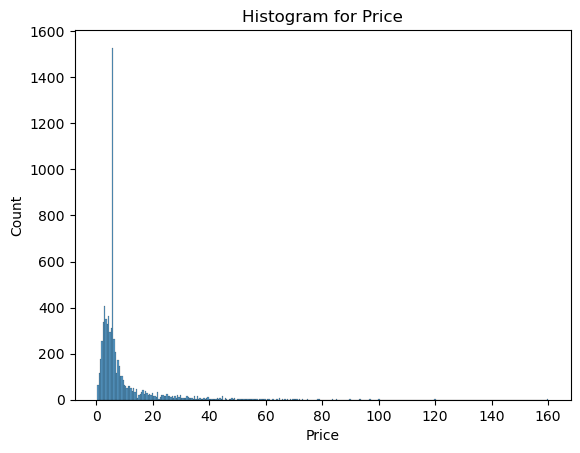

In [35]:
sns.histplot(car['Price'])
plt.title("Histogram for Price")

Text(0.5, 1.0, 'Boxplot for Price')

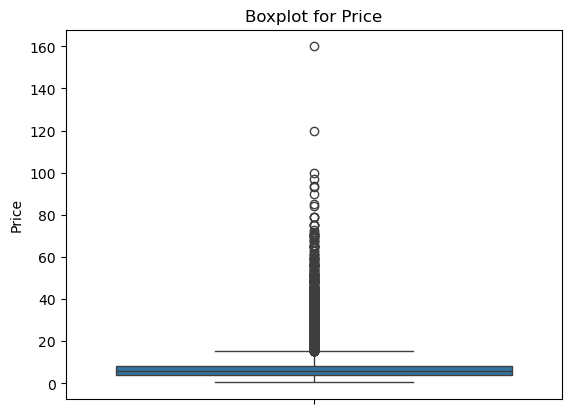

In [34]:
sns.boxplot(car['Price'])
plt.title("Boxplot for Price")

Text(0.5, 1.0, 'Histogram for Engine')

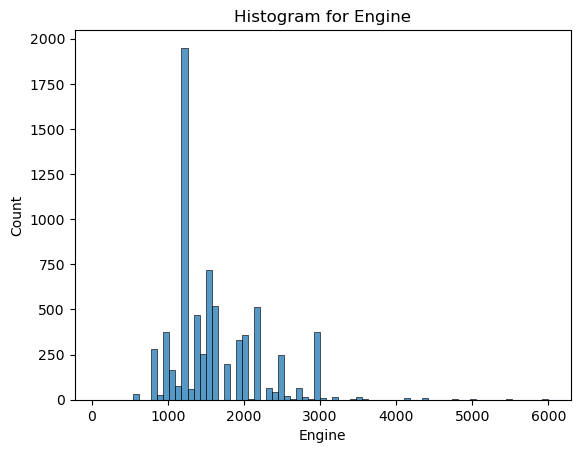

In [36]:
sns.histplot(car['Engine'])
plt.title("Histogram for Engine")

Text(0.5, 1.0, 'Boxplot for Engine')

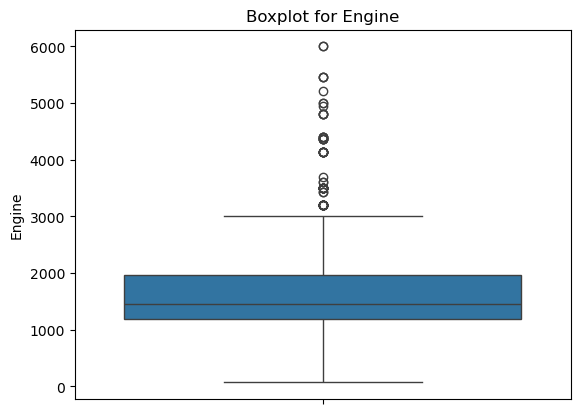

In [37]:
sns.boxplot(car['Engine'])
plt.title("Boxplot for Engine")

Text(0.5, 1.0, 'Histogram for Mileage')

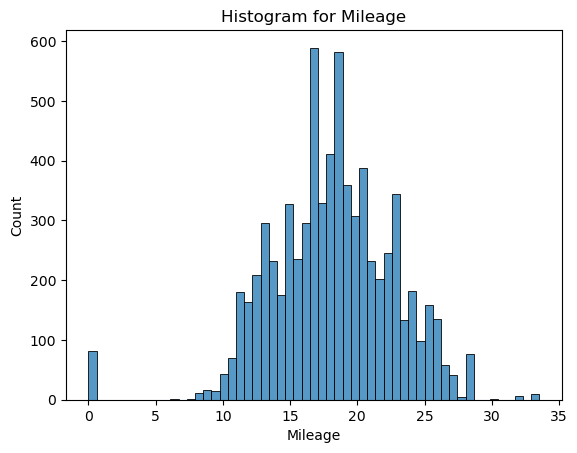

In [38]:
sns.histplot(car['Mileage'])
plt.title("Histogram for Mileage")

Text(0.5, 1.0, 'Boxplot for Mileage')

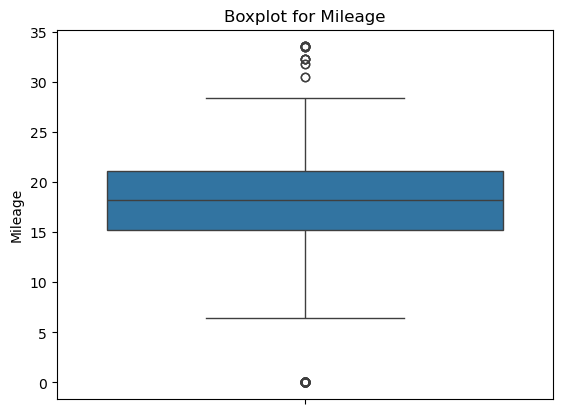

In [39]:
sns.boxplot(car['Mileage'])
plt.title("Boxplot for Mileage")

Plot bar charts showing the frequency of different Fuel_Type, Transmission, and Owner_Type.


<Figure size 500x300 with 0 Axes>

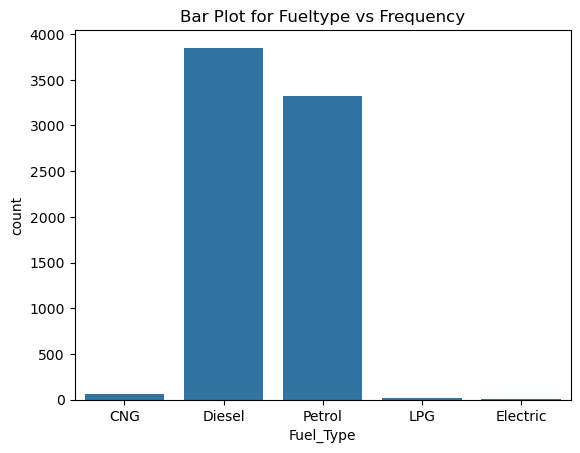

<Figure size 500x300 with 0 Axes>

In [ ]:
sns.countplot(x=car['Fuel_Type'], data=car).set_title('Bar Plot for Fueltype vs Frequency')
plt.figure(figsize=(5,3))

<Figure size 500x300 with 0 Axes>

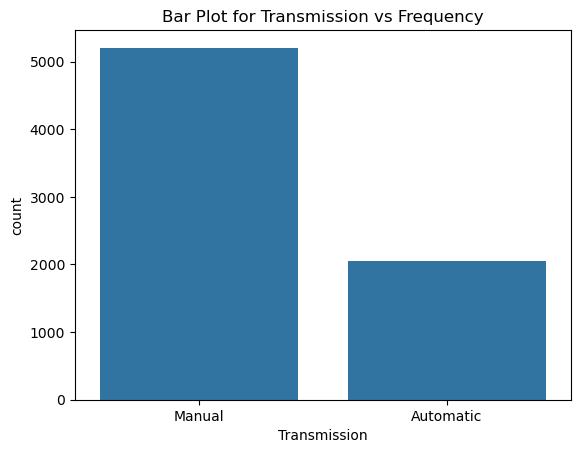

<Figure size 500x300 with 0 Axes>

In [49]:
sns.countplot(x=car['Transmission'], data=car).set_title('Bar Plot for Transmission vs Frequency')
plt.figure(figsize=(5,3))

<Figure size 500x300 with 0 Axes>

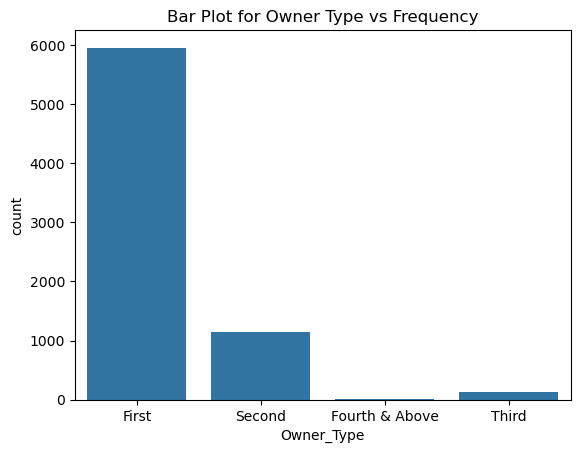

<Figure size 500x300 with 0 Axes>

In [50]:
sns.countplot(x=car['Owner_Type'], data=car).set_title('Bar Plot for Owner Type vs Frequency')
plt.figure(figsize=(5,3))

Visualize the trend of average car prices over Year of manufacture.

Text(0.5, 1.0, 'Average Price vs Year of Manufacture')

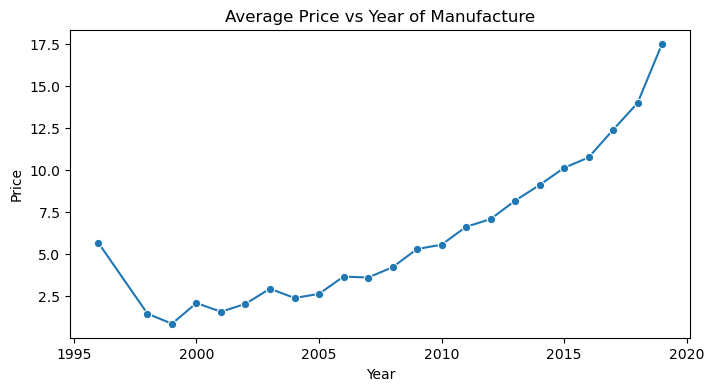

In [55]:
avg_price_by_year = car.groupby('Year')['Price'].mean().reset_index()
plt.figure(figsize=(8,4))
sns.lineplot(x='Year',y='Price',data=avg_price_by_year,marker='o')
plt.title('Average Price vs Year of Manufacture')

Compare price distributions across different Locations and Fuel_Types.

Text(0.5, 1.0, 'Price by Fuel Type')

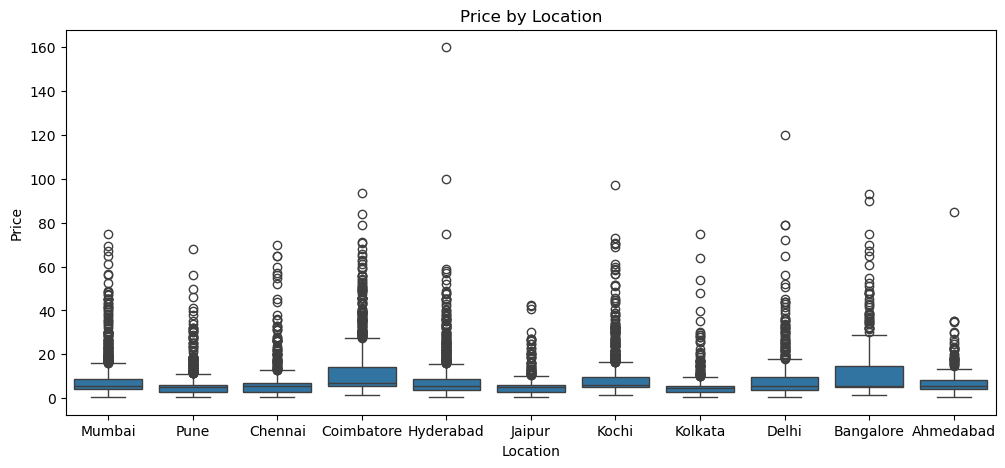

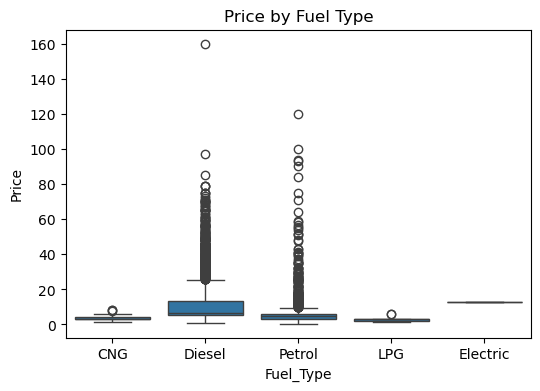

In [58]:
plt.figure(figsize=(12,5))
sns.boxplot(x='Location', y='Price', data=car)
plt.title('Price by Location')

plt.figure(figsize=(6,4))
sns.boxplot(x='Fuel_Type', y='Price', data=car)
plt.title('Price by Fuel Type')


# Correlation and Feature Relationships

Compute a correlation matrix for numerical columns and visualize it using a heatmap.

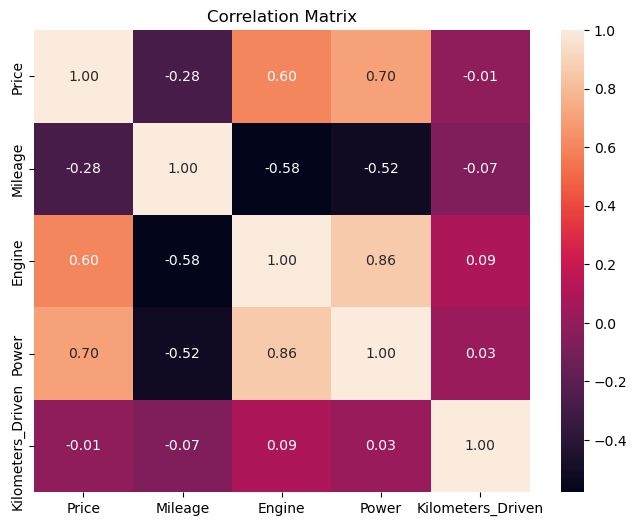

In [24]:
corr_cols = ['Price', 'Mileage', 'Engine', 'Power', 'Kilometers_Driven']
corr = car[corr_cols].corr()
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, fmt=".2f")
plt.title('Correlation Matrix')
plt.show()

Use scatter plots to analyze relationships between Price and key numerical variables (Mileage, Engine, Power, Kilometers_Driven).

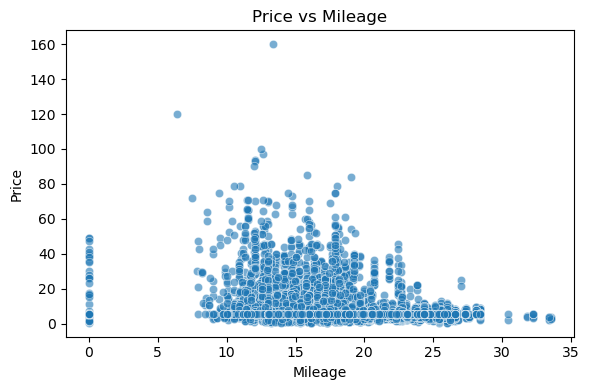

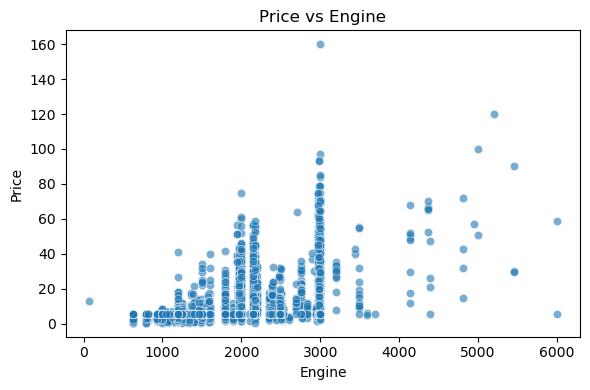

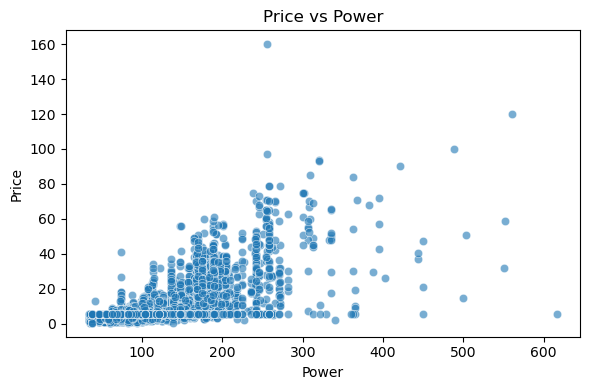

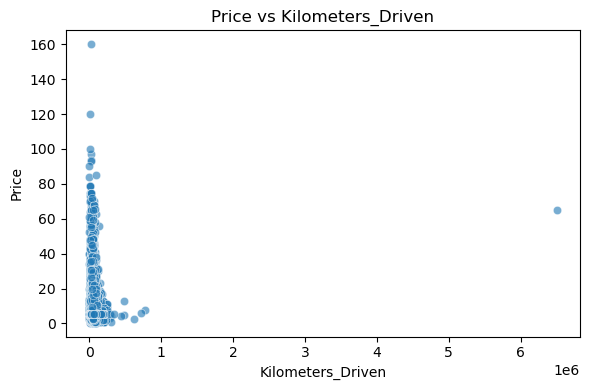

In [60]:
for col in ['Mileage', 'Engine', 'Power', 'Kilometers_Driven']:
    plt.figure(figsize=(6,4))
    sns.scatterplot(x=col, y='Price', data=car, alpha=0.6)
    plt.title(f'Price vs {col}')
    plt.tight_layout()
    plt.show()

Analyze multivariate interactions such as how Transmission and Fuel_Type together affect Price.

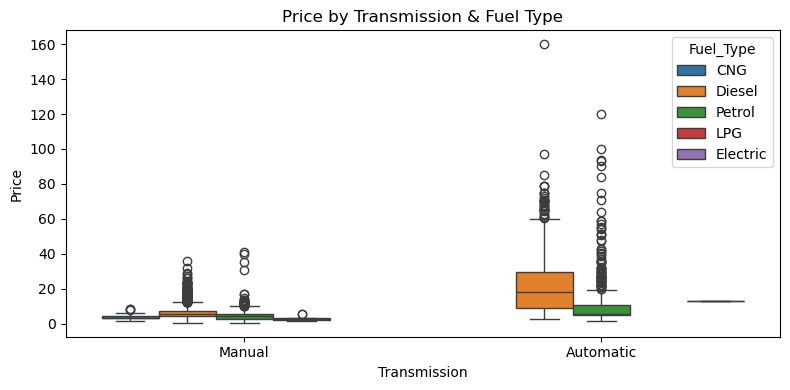

In [63]:
plt.figure(figsize=(8,4))
sns.boxplot(x='Transmission', y='Price', hue='Fuel_Type', data=car)
plt.title('Price by Transmission & Fuel Type')
plt.tight_layout()
plt.show()

## Outliers and Data Quality

Use boxplots to identify outliers in Price, Engine, and Power.

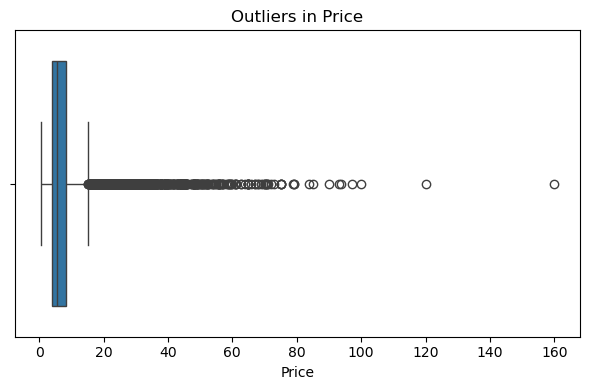

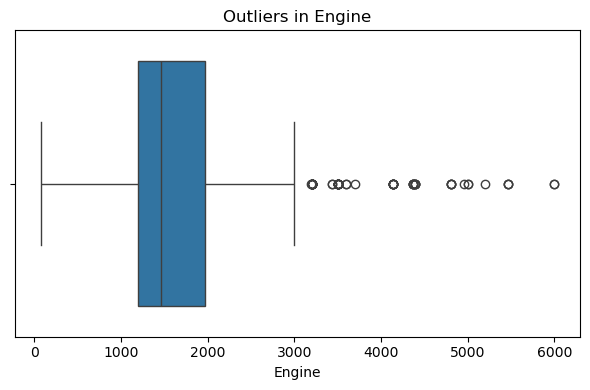

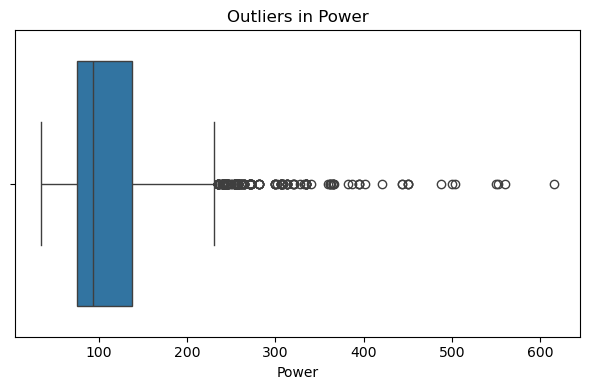

Number of Price outliers: 982


In [ ]:
for col in ['Price', 'Engine', 'Power']:
    plt.figure(figsize=(6,4))
    sns.boxplot(x=car[col])
    plt.title(f'Outliers in {col}')
    plt.tight_layout()
    plt.show()

Q1 = car['Price'].quantile(0.25)
Q3 = car['Price'].quantile(0.75)
IQR = Q3 - Q1
outliers_price = car[(car['Price'] < Q1 - 1.5*IQR) | (car['Price'] > Q3 + 1.5*IQR)]
print("Number of Price outliers:", len(outliers_price))

Identify features with possible inconsistencies (e.g., non-numeric Power, ambiguous Mileage units).

In [65]:
for col in ['Mileage', 'Engine', 'Power']:
    print(f"\nSample values for {col}:")
    print(car[col].head())


Sample values for Mileage:
0    26.60
1    19.67
2    18.20
3    20.77
4    15.20
Name: Mileage, dtype: float64

Sample values for Engine:
0     998
1    1582
2    1199
3    1248
4    1968
Name: Engine, dtype: int64

Sample values for Power:
0     58.16
1    126.20
2     88.70
3     88.76
4    140.80
Name: Power, dtype: float64


Analyze the New_Price feature and its missing data—what percentage is missing and how might this affect modeling?


In [ ]:
if 'New_Price' in car.columns:
    new_price_missing_pct = car['New_Price'].isna().mean()*100
    print(f"Percentage of missing New_Price: {new_price_missing_pct:.2f}%")


Percentage of missing New_Price: 86.13%


## Insights and Trends

Top 10 most expensive cars:


,S.No.,Name,Location,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,New_Price,Price
4079,4079,Land Rover Range Rover 3.0 Diesel LWB Vogue,Hyderabad,2017,25000,Diesel,Automatic,First,13.33,2993,255.00,5.0,2.30,160.00
5781,5781,Lamborghini Gallardo Coupe,Delhi,2011,6500,Petrol,Automatic,Third,6.40,5204,560.00,2.0,NaN,120.00
5919,5919,Jaguar F Type 5.0 V8 S,Hyderabad,2015,8000,Petrol,Automatic,First,12.50,5000,488.10,2.0,NaN,100.00
1505,1505,Land Rover Range Rover Sport SE,Kochi,2019,26013,Diesel,Automatic,First,12.65,2993,255.00,5.0,1.39,97.07
1974,1974,BMW 7 Series 740Li,Coimbatore,2018,28060,Petrol,Automatic,First,12.05,2979,320.00,5.0,NaN,93.67
1984,1984,BMW 7 Series 740Li,Bangalore,2017,17465,Petrol,Automatic,First,12.05,2979,320.00,5.0,NaN,93.00
4691,4691,Mercedes-Benz SLK-Class 55 AMG,Bangalore,2014,3000,Petrol,Automatic,Second,12.00,5461,421.00,2.0,NaN,90.00
5535,5535,BMW X6 xDrive 40d M Sport,Ahmedabad,2015,97003,Diesel,Automatic,First,15.87,2993,308.43,5.0,NaN,85.00
2095,2095,Mercedes-Benz SLC 43 AMG,Coimbatore,2019,2526,Petrol,Automatic,First,19.00,2996,362.07,2.0,1.06,83.96
1885,1885,Mercedes-Benz GLS 350d Grand Edition,Delhi,2018,6000,Diesel,Automatic,First,11.00,2987,258.00,7.0,1.02,79.00


Top 10 least expensive cars:


,S.No.,Name,Location,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,New_Price,Price
1713,1713,Tata Nano Lx,Pune,2011,65000,Petrol,Manual,Second,26.0,624,35.0,4.0,NaN,0.44
2847,2847,Hyundai Getz GLS,Pune,2005,86000,Petrol,Manual,Second,15.3,1341,83.0,5.0,NaN,0.45
1628,1628,Maruti 800 Std BSIII,Jaipur,2004,12000,Petrol,Manual,Second,16.1,796,37.0,4.0,NaN,0.45
3138,3138,Maruti Zen LXI,Jaipur,1998,95150,Petrol,Manual,Third,17.3,993,60.0,5.0,NaN,0.45
3228,3228,Maruti 800 Std,Pune,2003,52000,Petrol,Manual,First,16.1,796,37.0,4.0,NaN,0.50
2605,2605,Tata Nano Cx,Jaipur,2010,57000,Petrol,Manual,First,26.0,624,35.0,4.0,NaN,0.50
5657,5657,Maruti 800 Std,Jaipur,2002,75000,Petrol,Manual,First,16.1,796,37.0,4.0,NaN,0.51
5716,5716,Maruti Zen LX,Jaipur,1998,95150,Petrol,Manual,Third,17.3,993,60.0,5.0,NaN,0.53
4965,4965,Tata Nano STD SE,Jaipur,2012,80000,Petrol,Manual,Second,25.4,624,37.5,4.0,NaN,0.53
274,274,Maruti Zen VXI BSII,Mumbai,2002,60000,Petrol,Manual,Third,17.3,993,60.0,5.0,NaN,0.55


Average Price by Owner Type:


,Owner_Type,Price
0,First,9.219525
1,Fourth & Above,3.870000
2,Second,7.286849
3,Third,5.118102


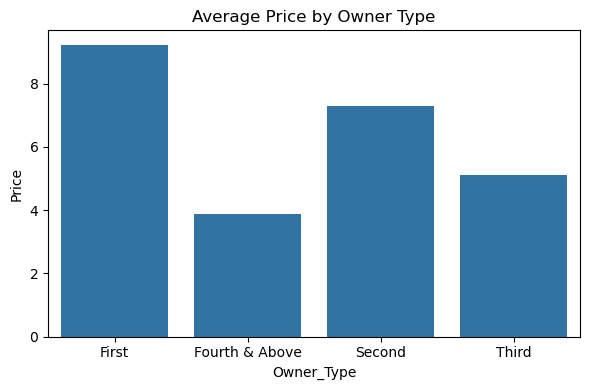

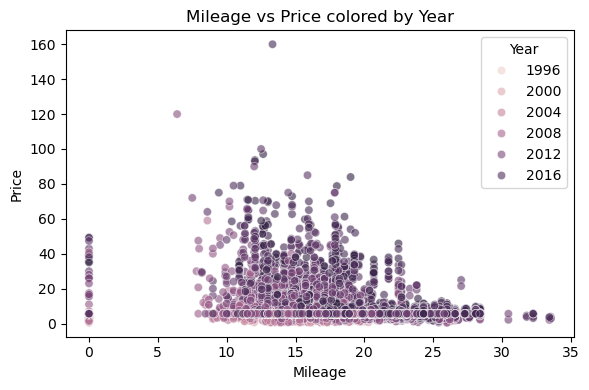

In [68]:
# Most and least expensive cars
top_10 = car.sort_values('Price', ascending=False).head(10)
bottom_10 = car.sort_values('Price', ascending=True).head(10)

print("Top 10 most expensive cars:")
display(top_10)

print("Top 10 least expensive cars:")
display(bottom_10)

# Average price vs number of previous owners
if 'Owner_Type' in car.columns:
    avg_price_by_owner = car.groupby('Owner_Type')['Price'].mean().reset_index()
    print("Average Price by Owner Type:")
    display(avg_price_by_owner)

    plt.figure(figsize=(6,4))
    sns.barplot(x='Owner_Type', y='Price', data=avg_price_by_owner)
    plt.title('Average Price by Owner Type')
    plt.tight_layout()
    plt.show()

# Mileage vs price and year
if 'Year' in car.columns:
    plt.figure(figsize=(6,4))
    sns.scatterplot(x='Mileage', y='Price', hue='Year', data=car, alpha=0.6)
    plt.title('Mileage vs Price colored by Year')
    plt.tight_layout()
    plt.show()